# **Product Line Profitability & Margin Performance Analysis for Nassau Candy Distributor**

## 1. Libraries and Dataset Loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv


In [3]:
df = pd.read_csv(next(iter(uploaded)))

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 10194
Columns: 18


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
count,10194.000000,10194,10194,10194,10194,10194.000000,10194,10194,10194,10194,10194,10194,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
unique,NaN,8549,717,1338,4,NaN,2,542,59,654,3,4,15,15,NaN,NaN,NaN,NaN
top,NaN,US-2022-130974-CHO-SCR-58000,02-09-2025,07-06-2028,Standard Class,NaN,United States,New York City,California,10035,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,NaN,NaN,NaN,NaN
freq,NaN,5,62,38,6120,NaN,9994,915,2001,263,9844,3253,2137,2137,NaN,NaN,NaN,NaN
mean,5097.500000,NaN,NaN,NaN,NaN,134468.961154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.908537,3.791838,9.166451,4.742087
std,2942.898656,NaN,NaN,NaN,NaN,20231.483007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.341020,2.228317,6.643740,5.061647
min,1.000000,NaN,NaN,NaN,NaN,100006.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,NaN,NaN,NaN,NaN,117212.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,NaN,NaN,NaN,NaN,133550.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,NaN,NaN,NaN,NaN,152051.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,5.000000,12.250000,5.700000


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [8]:
print("Total Duplicate Rows:", df.duplicated().sum())

Total Duplicate Rows: 0


## 2. Data Cleaning and Preparation

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [10]:
print("Order Date Range:")
print(df['Order Date'].min(), "to", df['Order Date'].max())

print("\nShip Date Range:")
print(df['Ship Date'].min(), "to", df['Ship Date'].max())

Order Date Range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date Range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [11]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [12]:
print("Shipping Days Statistics:")
print(df['Shipping Days'].describe())

Shipping Days Statistics:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Days, dtype: float64


In [13]:
print("Unique Shipping Days:")
print(df['Shipping Days'].value_counts().sort_index().head(20))

Unique Shipping Days:
Shipping Days
904       89
905       40
906      289
907      176
908      591
909      519
910      207
911      134
912        4
915        2
1269     258
1270     156
1271     610
1272     456
1273    1326
1274    1035
1275     612
1276     293
1277      18
1634       3
Name: count, dtype: int64


In [14]:
df[['Order Date', 'Ship Date', 'Shipping Days']].tail(10)

,Order Date,Ship Date,Shipping Days
10184,2025-12-29,2030-06-25,1639
10185,2025-12-29,2030-06-25,1639
10186,2025-12-30,2030-06-26,1639
10187,2025-12-30,2030-06-28,1641
10188,2025-12-30,2030-06-26,1639
10189,2025-12-30,2030-06-26,1639
10190,2025-12-30,2030-06-26,1639
10191,2025-12-30,2030-06-26,1639
10192,2025-12-30,2030-06-26,1639
10193,2025-12-30,2030-06-26,1639


In [15]:
# Gross Margin Percentage
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

# Profit per Unit
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

# Profit Margin Check
df[['Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost',
    'Gross Margin %', 'Profit per Unit']].head()

,Product Name,Sales,Units,Gross Profit,Cost,Gross Margin %,Profit per Unit
0,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11
1,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45
2,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49
3,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50
4,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45


In [16]:
print("Gross Margin % Statistics:")
print(df['Gross Margin %'].describe())

print("\nProfit per Unit Statistics:")
print(df['Profit per Unit'].describe())

Gross Margin % Statistics:
count    10194.000000
mean        66.514045
std          6.721012
min          7.692308
25%         65.333333
50%         66.666667
75%         69.444444
max         80.000000
Name: Gross Margin %, dtype: float64

Profit per Unit Statistics:
count    10194.000000
mean         2.412539
std          0.806007
min          0.250000
25%          2.400000
50%          2.450000
75%          2.490000
max         10.000000
Name: Profit per Unit, dtype: float64


## 3. Division-wise Profitability Analysis

In [17]:
# Product Line / Division Profitability

division_analysis = df.groupby('Division').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

division_analysis['Gross Margin %'] = (
    division_analysis['Total_Gross_Profit'] /
    division_analysis['Total_Sales']
) * 100

division_analysis['Profit per Unit'] = (
    division_analysis['Total_Gross_Profit'] /
    division_analysis['Total_Units']
)

division_analysis

,Division,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,Chocolate,131692.90,37275,88824.62,42868.28,67.448298,2.382954
1,Other,9663.25,1242,4333.45,5329.80,44.844643,3.489090
2,Sugar,427.48,137,284.73,142.75,66.606625,2.078321


In [18]:
division_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

,Division,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,Chocolate,131692.90,37275,88824.62,42868.28,67.448298,2.382954
1,Other,9663.25,1242,4333.45,5329.80,44.844643,3.489090
2,Sugar,427.48,137,284.73,142.75,66.606625,2.078321


In [19]:
division_analysis.sort_values(
    by='Gross Margin %',
    ascending=False
)

,Division,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,Chocolate,131692.90,37275,88824.62,42868.28,67.448298,2.382954
2,Sugar,427.48,137,284.73,142.75,66.606625,2.078321
1,Other,9663.25,1242,4333.45,5329.80,44.844643,3.489090


## 4. Product-level Profitability Analysis

In [20]:
# Product-level Profitability

product_analysis = df.groupby(
    ['Product ID', 'Product Name']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

product_analysis['Gross Margin %'] = (
    product_analysis['Total_Gross_Profit'] /
    product_analysis['Total_Sales']
) * 100

product_analysis['Profit per Unit'] = (
    product_analysis['Total_Gross_Profit'] /
    product_analysis['Total_Units']
)

product_analysis.head()

,Product ID,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80,66.666667,2.40
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,6755.00,71.346705,2.49
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,8517.30,69.444444,2.50
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.333333,2.45


In [21]:
# Top 10 Products according to total Gross Profit

top_10_profit = product_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
).head(10)

top_10_profit

,Product ID,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,8517.30,69.444444,2.50
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.333333,2.45
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,6755.00,71.346705,2.49
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80,66.666667,2.40
8,OTH-LIC-15000,Lickable Wallpaper,7860.00,393,3930.00,3930.00,50.000000,10.00
6,OTH-GUM-21000,Wonka Gum,597.50,478,310.70,286.80,52.000000,0.65
9,SUG-EVE-47000,Everlasting Gobstopper,130.00,13,104.00,26.00,80.000000,8.00
7,OTH-KAZ-38000,Kazookles,1205.75,371,92.75,1113.00,7.692308,0.25
11,SUG-HAI-55000,Hair Toffee,76.50,17,59.50,17.00,77.777778,3.50


In [22]:
# Top 10 Gross Margin %

top_10_margin = product_analysis.sort_values(
    by='Gross Margin %',
    ascending=False
).head(10)

top_10_margin

,Product ID,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
9,SUG-EVE-47000,Everlasting Gobstopper,130.00,13,104.00,26.00,80.000000,8.00
11,SUG-HAI-55000,Hair Toffee,76.50,17,59.50,17.00,77.777778,3.50
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,6755.00,71.346705,2.49
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,8517.30,69.444444,2.50
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80,66.666667,2.40
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.333333,2.45
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11
12,SUG-LAF-25000,Laffy Taffy,53.73,27,33.48,20.25,62.311558,1.24
5,OTH-FIZ-56000,Fizzy Lifting Drinks,78.75,21,47.25,31.50,60.000000,2.25
6,OTH-GUM-21000,Wonka Gum,597.50,478,310.70,286.80,52.000000,0.65


In [23]:
# Identify Low-margin products

low_margin_products = product_analysis.sort_values(
    by='Gross Margin %',
    ascending=True
).head(10)

low_margin_products

,Product ID,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
7,OTH-KAZ-38000,Kazookles,1205.75,371,92.75,1113.00,7.692308,0.25
10,SUG-FUN-75000,Fun Dip,12.00,8,4.80,7.20,40.000000,0.60
13,SUG-NER-92000,Nerds,15.00,10,7.00,8.00,46.666667,0.70
14,SUG-SWE-91000,SweeTARTS,61.50,41,28.70,32.80,46.666667,0.70
8,OTH-LIC-15000,Lickable Wallpaper,7860.00,393,3930.00,3930.00,50.000000,10.00
6,OTH-GUM-21000,Wonka Gum,597.50,478,310.70,286.80,52.000000,0.65
5,OTH-FIZ-56000,Fizzy Lifting Drinks,78.75,21,47.25,31.50,60.000000,2.25
12,SUG-LAF-25000,Laffy Taffy,53.73,27,33.48,20.25,62.311558,1.24
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.333333,2.45


In [24]:
# Highest Profit-per-Unit products

top_profit_per_unit = product_analysis.sort_values(
    by='Profit per Unit',
    ascending=False
).head(10)

top_profit_per_unit

,Product ID,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
8,OTH-LIC-15000,Lickable Wallpaper,7860.00,393,3930.00,3930.00,50.000000,10.00
9,SUG-EVE-47000,Everlasting Gobstopper,130.00,13,104.00,26.00,80.000000,8.00
11,SUG-HAI-55000,Hair Toffee,76.50,17,59.50,17.00,77.777778,3.50
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,8517.30,69.444444,2.50
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,6755.00,71.346705,2.49
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.333333,2.45
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80,66.666667,2.40
5,OTH-FIZ-56000,Fizzy Lifting Drinks,78.75,21,47.25,31.50,60.000000,2.25
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11
12,SUG-LAF-25000,Laffy Taffy,53.73,27,33.48,20.25,62.311558,1.24


## 5. Pareto Analysis

In [25]:
# Pareto Analysis

pareto = product_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
).copy()

In [26]:
pareto['Cumulative Profit'] = pareto['Total_Gross_Profit'].cumsum()

total_profit = pareto['Total_Gross_Profit'].sum()

pareto['Cumulative Profit %'] = (
    pareto['Cumulative Profit'] / total_profit
) * 100

pareto['Product Rank'] = range(1, len(pareto) + 1)

In [27]:
pareto[
    ['Product Rank', 'Product ID', 'Product Name',
     'Total_Gross_Profit', 'Cumulative Profit %']
].head(15)

,Product Rank,Product ID,Product Name,Total_Gross_Profit,Cumulative Profit %
3,1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
4,2,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023
1,3,CHO-MIL-31000,Wonka Bar - Milk Chocolate,17443.37,59.299454
2,4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717
0,5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,16593.60,95.057747
8,6,OTH-LIC-15000,Lickable Wallpaper,3930.00,99.263528
6,7,OTH-GUM-21000,Wonka Gum,310.70,99.596031
9,8,SUG-EVE-47000,Everlasting Gobstopper,104.00,99.707329
7,9,OTH-KAZ-38000,Kazookles,92.75,99.806588
11,10,SUG-HAI-55000,Hair Toffee,59.50,99.870263


In [28]:

pareto_80 = pareto[
    pareto['Cumulative Profit %'] <= 80
]

print("Products contributing up to 80% of total Gross Profit:",
      len(pareto_80))

print("Total Products:", len(pareto))

Products contributing up to 80% of total Gross Profit: 4
Total Products: 15


In [29]:
print(
    pareto[
        pareto['Cumulative Profit %'] >= 80
    ][
        ['Product Rank', 'Product ID', 'Product Name',
         'Cumulative Profit %']
    ].head(1)
)

   Product Rank     Product ID               Product Name  Cumulative Profit %
0             5  CHO-FUD-51000  Wonka Bar - Fudge Mallows            95.057747


In [30]:
top_4_profit = pareto.head(4)['Total_Gross_Profit'].sum()

total_profit = pareto['Total_Gross_Profit'].sum()

top_4_percentage = (top_4_profit / total_profit) * 100

print(f"Top 4 products contribution to total gross profit: {top_4_percentage:.2f}%")

Top 4 products contribution to total gross profit: 77.30%


In [31]:
pareto = product_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
).reset_index(drop=True)

## The Pareto analysis shows that the top four products contribute approximately 77.3% of total gross profit, indicating that a small number of products drive the majority of profitability. The addition of the fifth product increases cumulative gross profit contribution to approximately 95.1%.

In [68]:
# Pareto Analysis - Product Gross Profit

pareto = product_analysis[['Product Name', 'Total_Gross_Profit']].copy()

# Highest gross profit first
pareto = pareto.sort_values(
    by='Total_Gross_Profit',
    ascending=False
).reset_index(drop=True)

# Cumulative gross profit
pareto['Cumulative_Gross_Profit'] = pareto['Total_Gross_Profit'].cumsum()

# Cumulative percentage
total_profit = pareto['Total_Gross_Profit'].sum()

pareto['Cumulative_Profit_%'] = (
    pareto['Cumulative_Gross_Profit'] / total_profit
) * 100

# Display top products
pareto.head(10)

,Product Name,Total_Gross_Profit,Cumulative_Gross_Profit,Cumulative_Profit_%
0,Wonka Bar -Scrumdiddlyumptious,19357.50,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,37967.70,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,55411.07,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,72231.02,77.299717
4,Wonka Bar - Fudge Mallows,16593.60,88824.62,95.057747
5,Lickable Wallpaper,3930.00,92754.62,99.263528
6,Wonka Gum,310.70,93065.32,99.596031
7,Everlasting Gobstopper,104.00,93169.32,99.707329
8,Kazookles,92.75,93262.07,99.806588
9,Hair Toffee,59.50,93321.57,99.870263


In [69]:
pareto[pareto['Cumulative_Profit_%'] <= 80]

,Product Name,Total_Gross_Profit,Cumulative_Gross_Profit,Cumulative_Profit_%
0,Wonka Bar -Scrumdiddlyumptious,19357.50,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,37967.70,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,55411.07,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,72231.02,77.299717


In [70]:
pareto[pareto['Cumulative_Profit_%'] >= 80].head(1)

,Product Name,Total_Gross_Profit,Cumulative_Gross_Profit,Cumulative_Profit_%
4,Wonka Bar - Fudge Mallows,16593.6,88824.62,95.057747


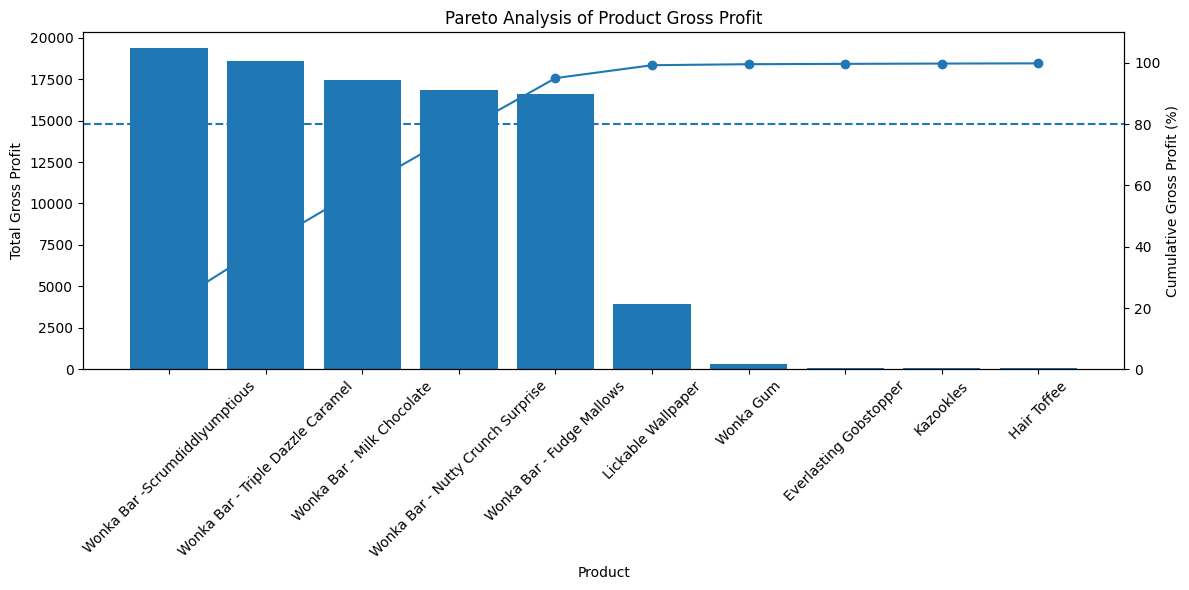

In [71]:
import matplotlib.pyplot as plt

top_n = 10
pareto_top = pareto.head(top_n)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    pareto_top['Product Name'],
    pareto_top['Total_Gross_Profit']
)

ax1.set_xlabel('Product')
ax1.set_ylabel('Total Gross Profit')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    pareto_top['Product Name'],
    pareto_top['Cumulative_Profit_%'],
    marker='o'
)

ax2.axhline(80, linestyle='--')
ax2.set_ylabel('Cumulative Gross Profit (%)')
ax2.set_ylim(0, 110)

plt.title('Pareto Analysis of Product Gross Profit')
plt.tight_layout()
plt.show()

## 6. Region-wise Analysis

In [32]:
# Region-wise Analysis

region_analysis = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

region_analysis['Gross Margin %'] = (
    region_analysis['Total_Gross_Profit'] /
    region_analysis['Total_Sales']
) * 100

region_analysis['Profit per Unit'] = (
    region_analysis['Total_Gross_Profit'] /
    region_analysis['Total_Units']
)

region_analysis = region_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

region_analysis

,Region,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
3,Pacific,46301.53,12466,30485.94,15815.59,65.842187,2.445527
0,Atlantic,41197.24,11159,26973.70,14223.54,65.474532,2.417215
2,Interior,32037.60,8820,21282.49,10755.11,66.429726,2.412981
1,Gulf,22247.26,6209,14700.67,7546.59,66.078564,2.367639


- Pacific has the highest Sales and Total Gross Profit.

- Interior has the highest Gross Margin % (66.43%).
- Pacific also has the highest Profit per Unit (2.45).
- Gulf has the lowest Sales and Gross Profit among the four regions.
- Overall, margins are relatively close across regions, while profitability volume differs more significantly. **bold text**



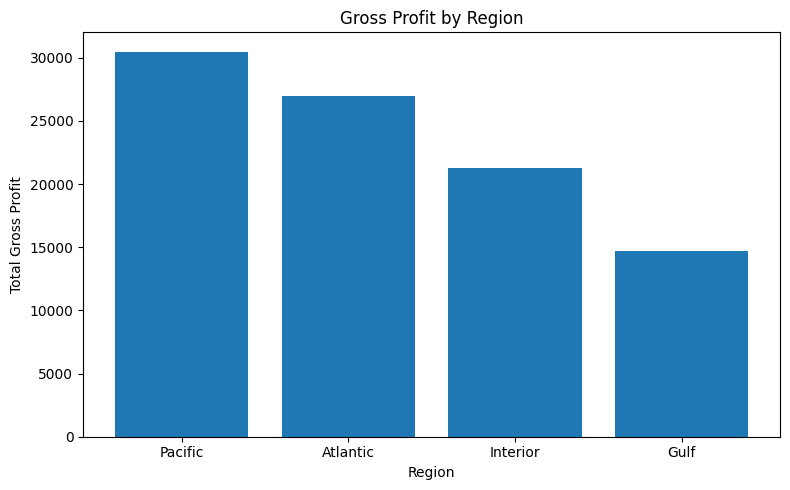

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Total_Gross_Profit']
)

plt.title('Gross Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Gross Profit')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

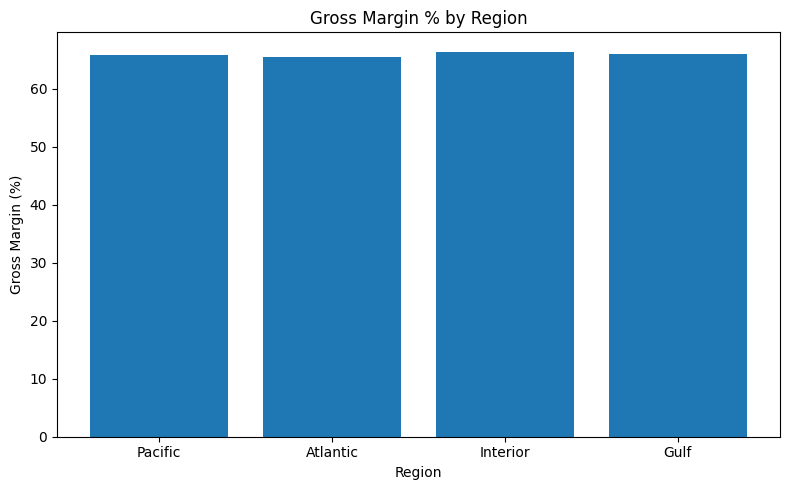

In [34]:
# Region-wise Gross Margin Chart

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Gross Margin %']
)

plt.title('Gross Margin % by Region')
plt.xlabel('Region')
plt.ylabel('Gross Margin (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

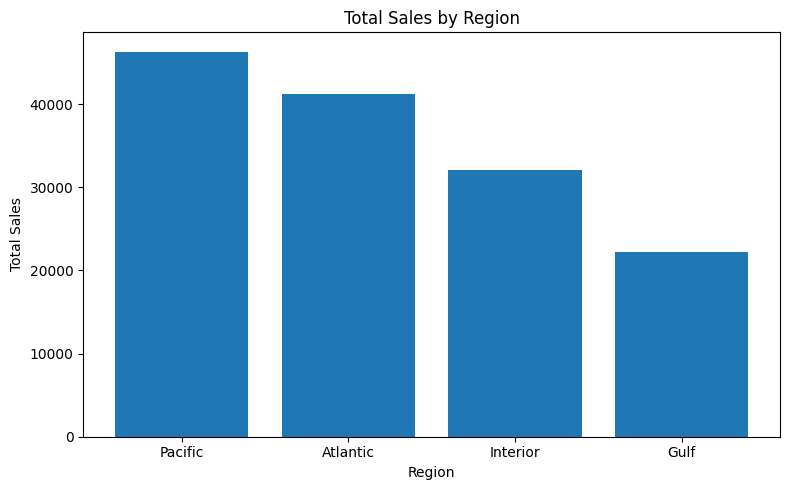

In [35]:
# Region-wise Sales Chart

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Total_Sales']
)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 7. State-wise Analysis

In [36]:
# State-wise Analysis

state_analysis = df.groupby('State/Province').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

state_analysis['Gross Margin %'] = (
    state_analysis['Total_Gross_Profit'] /
    state_analysis['Total_Sales']
) * 100

state_analysis['Profit per Unit'] = (
    state_analysis['Total_Gross_Profit'] /
    state_analysis['Total_Units']
)

state_analysis = state_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

state_analysis.head(10)

,State/Province,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
5,California,27917.40,7667,18479.42,9437.98,66.193199,2.410254
34,New York,15541.03,4224,10222.44,5318.59,65.777107,2.420085
51,Texas,13416.09,3724,8909.53,4506.56,66.409289,2.392462
43,Pennsylvania,8027.03,2153,5225.47,2801.56,65.098424,2.427065
55,Washington,6921.15,1883,4566.64,2354.51,65.980942,2.425194
13,Illinois,6898.96,1845,4557.68,2341.28,66.063291,2.470287
39,Ohio,6768.95,1759,4413.03,2355.92,65.195193,2.508829
10,Florida,4804.02,1379,3207.11,1596.91,66.758881,2.325678
36,North Carolina,3450.86,983,2331.16,1119.70,67.553016,2.371475
2,Arizona,3587.55,862,2290.11,1297.44,63.834929,2.656740


- California has the highest Sales and Gross Profit among the top 10 states.
- North Carolina has the highest Gross Margin in this Top 10 list: 67.55%.
- Arizona has the highest Profit per Unit: 2.66.
- Ohio also has relatively strong Profit per Unit: 2.51.
- California's high gross profit is mainly associated with its much larger sales volume.

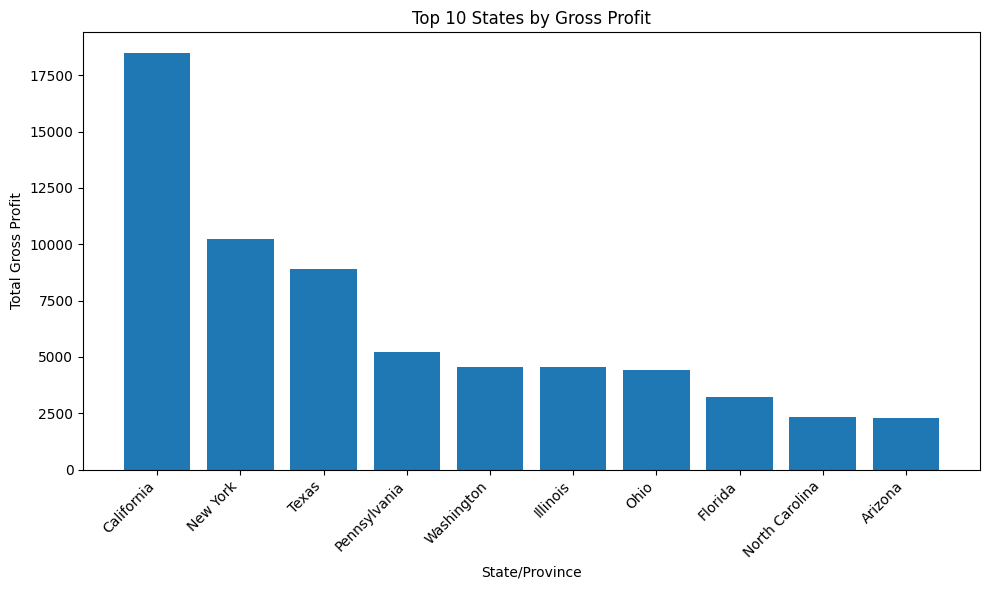

In [37]:
# Chart 1 — Top 10 States by Gross Profit

top10_states = state_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10_states['State/Province'],
    top10_states['Total_Gross_Profit']
)

plt.title('Top 10 States by Gross Profit')
plt.xlabel('State/Province')
plt.ylabel('Total Gross Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

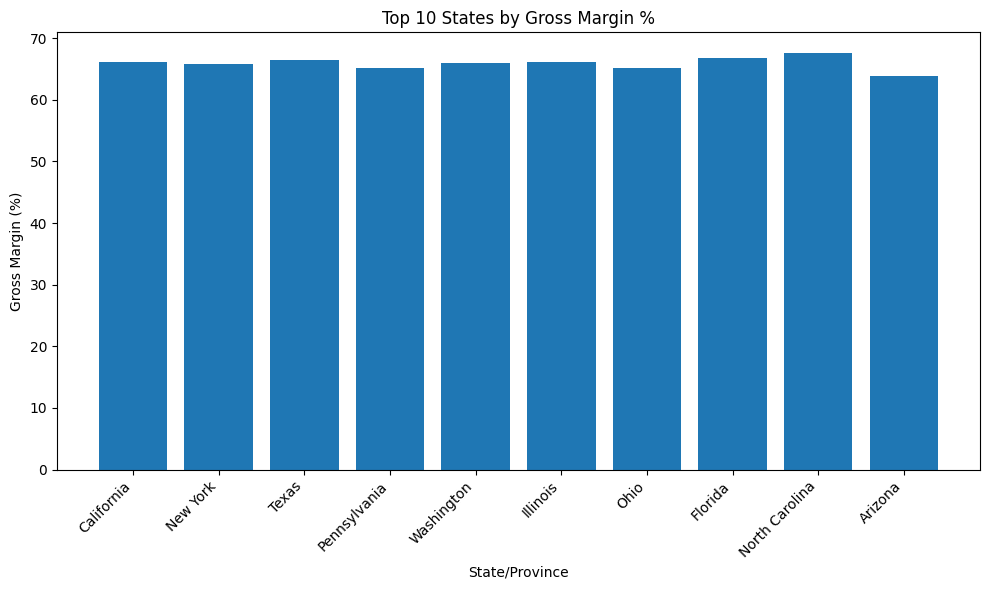

In [38]:
# Chart 2 — Top 10 States by Gross Margin

plt.figure(figsize=(10, 6))

plt.bar(
    top10_states['State/Province'],
    top10_states['Gross Margin %']
)

plt.title('Top 10 States by Gross Margin %')
plt.xlabel('State/Province')
plt.ylabel('Gross Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

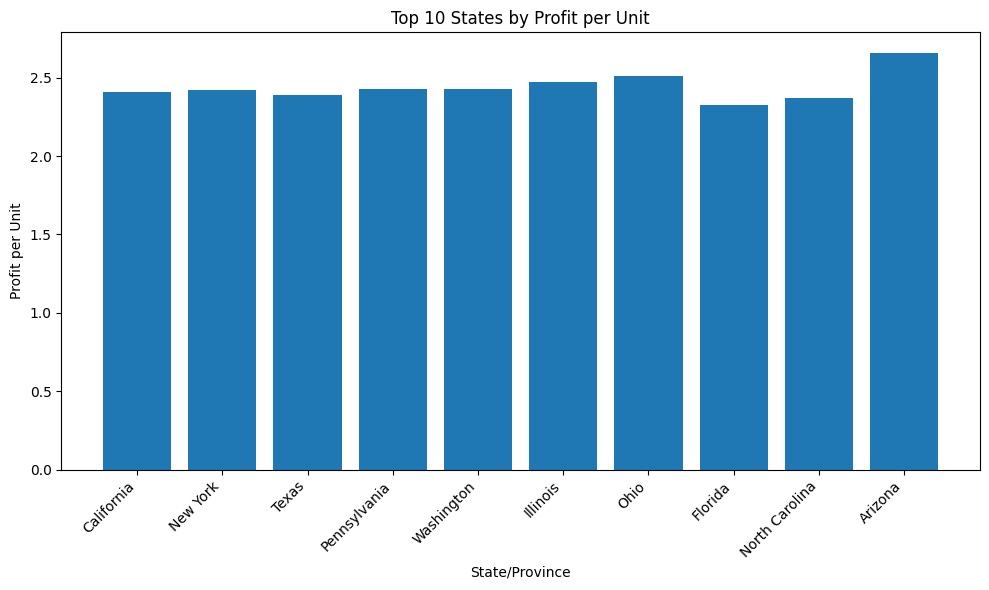

In [39]:
# Chart 3 — Top 10 States by Profit per Unit

plt.figure(figsize=(10, 6))

plt.bar(
    top10_states['State/Province'],
    top10_states['Profit per Unit']
)

plt.title('Top 10 States by Profit per Unit')
plt.xlabel('State/Province')
plt.ylabel('Profit per Unit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## 8. Time-based Analysis

In [40]:
# Year & Month columns create

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

In [41]:
monthly_analysis = df.groupby(
    ['Year', 'Month', 'Month Name']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

monthly_analysis['Gross Margin %'] = (
    monthly_analysis['Total_Gross_Profit'] /
    monthly_analysis['Total_Sales']
) * 100

monthly_analysis['Profit per Unit'] = (
    monthly_analysis['Total_Gross_Profit'] /
    monthly_analysis['Total_Units']
)

monthly_analysis = monthly_analysis.sort_values(
    ['Year', 'Month']
)

monthly_analysis.head(15)

,Year,Month,Month Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,2024,1,Jan,2093.90,566,1366.14,727.76,65.243803,2.413675
1,2024,2,Feb,1379.87,398,908.59,471.28,65.846058,2.282889
2,2024,3,Mar,4138.90,1125,2671.16,1467.74,64.537921,2.374364
3,2024,4,Apr,3988.22,1079,2612.81,1375.41,65.513186,2.421511
4,2024,5,May,3951.52,1099,2615.44,1336.08,66.188201,2.379836
5,2024,6,Jun,3518.76,1010,2330.72,1188.04,66.236970,2.307644
6,2024,7,Jul,3865.38,1107,2565.26,1300.12,66.365015,2.317308
7,2024,8,Aug,4477.65,1227,2945.87,1531.78,65.790537,2.400872
8,2024,9,Sep,7912.10,2105,5206.70,2705.40,65.806802,2.473492
9,2024,10,Oct,4815.98,1237,3119.46,1696.52,64.773110,2.521795


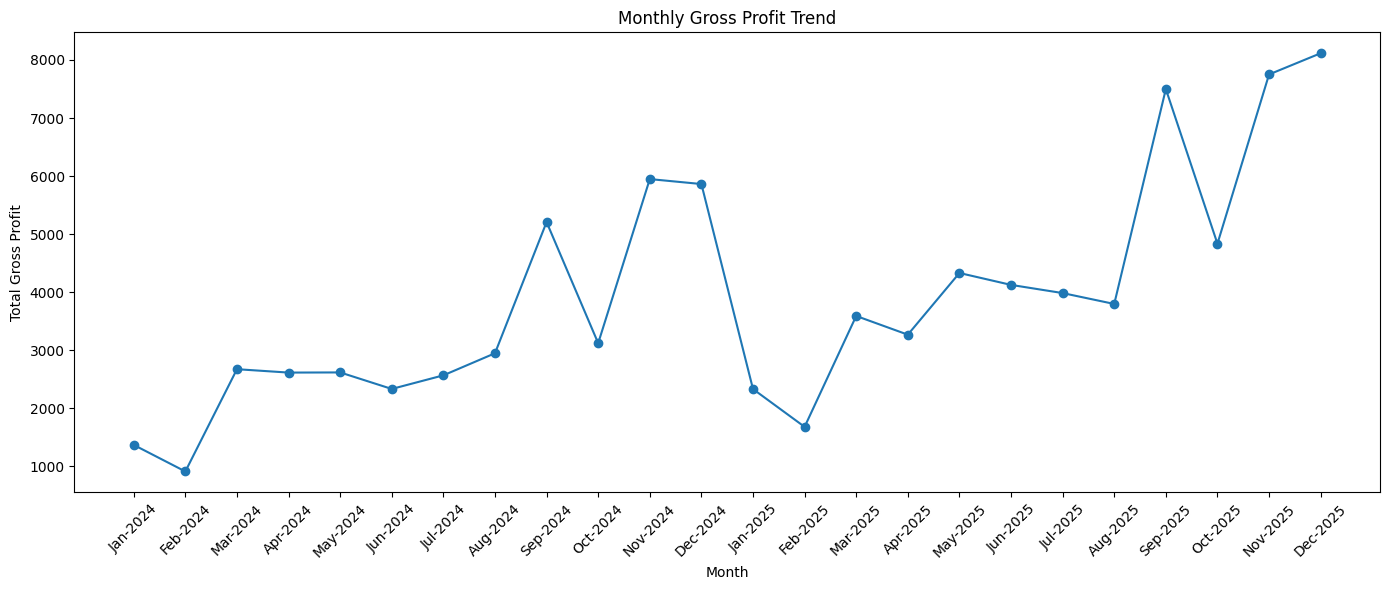

In [42]:
# Monthly Gross Profit Chart

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis['Month Name'] + '-' + monthly_analysis['Year'].astype(str),
    monthly_analysis['Total_Gross_Profit'],
    marker='o'
)

plt.title('Monthly Gross Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Gross Profit')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

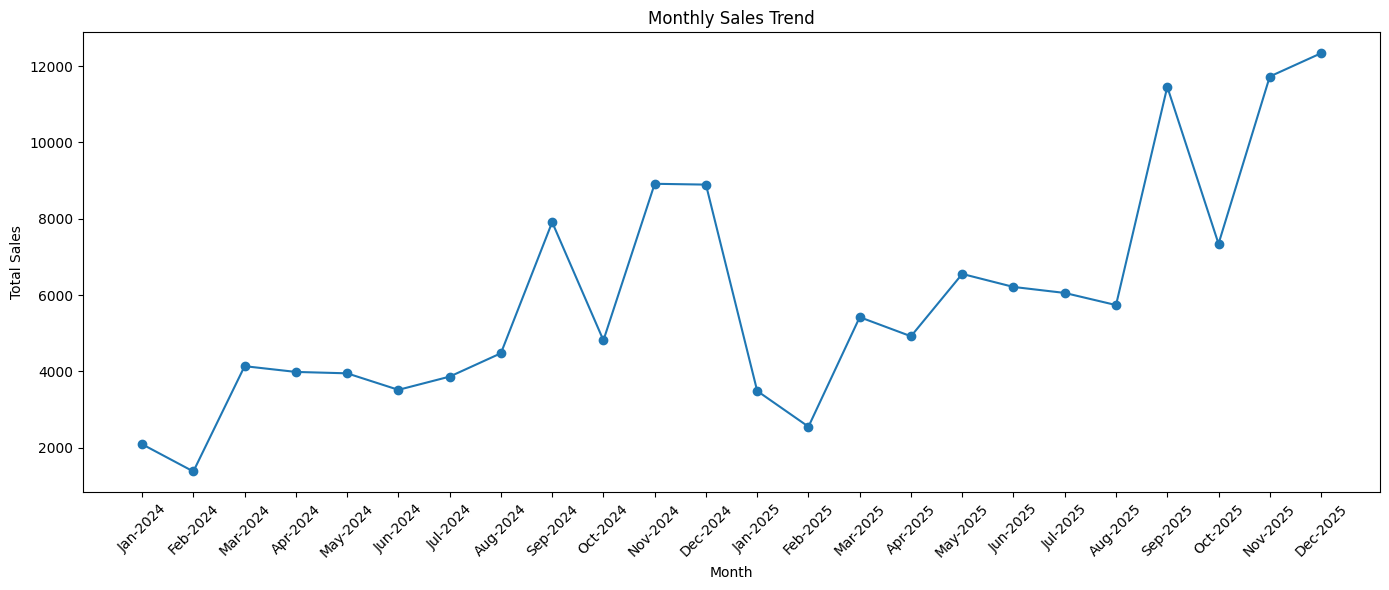

In [43]:
# Monthly Sales Trend Chart

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis['Month Name'] + '-' + monthly_analysis['Year'].astype(str),
    monthly_analysis['Total_Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [44]:
# Year-wise Profitability

yearly_analysis = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

yearly_analysis['Gross Margin %'] = (
    yearly_analysis['Total_Gross_Profit'] /
    yearly_analysis['Total_Sales']
) * 100

yearly_analysis['Profit per Unit'] = (
    yearly_analysis['Total_Gross_Profit'] /
    yearly_analysis['Total_Units']
)

yearly_analysis

,Year,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,2024,57956.20,15899,38151.43,19804.77,65.828039,2.399612
1,2025,83827.43,22755,55291.37,28536.06,65.958565,2.429856


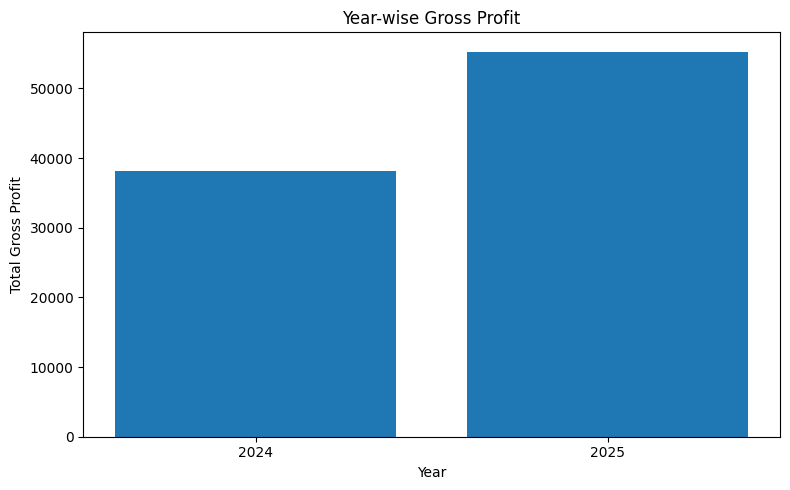

In [45]:
# Year-wise Gross Profit Chart

plt.figure(figsize=(8, 5))

plt.bar(
    yearly_analysis['Year'].astype(str),
    yearly_analysis['Total_Gross_Profit']
)

plt.title('Year-wise Gross Profit')
plt.xlabel('Year')
plt.ylabel('Total Gross Profit')
plt.tight_layout()

plt.show()

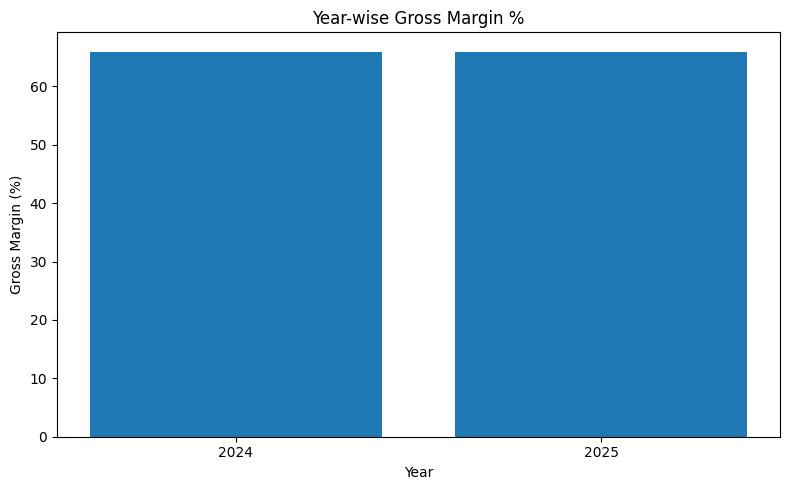

In [46]:
# Year-wise Gross Margin Chart

plt.figure(figsize=(8, 5))

plt.bar(
    yearly_analysis['Year'].astype(str),
    yearly_analysis['Gross Margin %']
)

plt.title('Year-wise Gross Margin %')
plt.xlabel('Year')
plt.ylabel('Gross Margin (%)')
plt.tight_layout()

plt.show()

In [47]:
# Best & Worst Months

# Highest and lowest Sales months
highest_sales = monthly_analysis.loc[
    monthly_analysis['Total_Sales'].idxmax()
]

lowest_sales = monthly_analysis.loc[
    monthly_analysis['Total_Sales'].idxmin()
]

# Highest and lowest Gross Profit months
highest_profit = monthly_analysis.loc[
    monthly_analysis['Total_Gross_Profit'].idxmax()
]

lowest_profit = monthly_analysis.loc[
    monthly_analysis['Total_Gross_Profit'].idxmin()
]

# Highest and lowest Gross Margin months
highest_margin = monthly_analysis.loc[
    monthly_analysis['Gross Margin %'].idxmax()
]

lowest_margin = monthly_analysis.loc[
    monthly_analysis['Gross Margin %'].idxmin()
]

print("Highest Sales Month:")
print(highest_sales)

print("\nLowest Sales Month:")
print(lowest_sales)

print("\nHighest Gross Profit Month:")
print(highest_profit)

print("\nLowest Gross Profit Month:")
print(lowest_profit)

print("\nHighest Gross Margin Month:")
print(highest_margin)

print("\nLowest Gross Margin Month:")
print(lowest_margin)

Highest Sales Month:
Year                       2025
Month                        12
Month Name                  Dec
Total_Sales            12338.27
Total_Units                3296
Total_Gross_Profit      8115.95
Total_Cost              4222.32
Gross Margin %        65.778671
Profit per Unit        2.462363
Name: 23, dtype: object

Lowest Sales Month:
Year                       2024
Month                         2
Month Name                  Feb
Total_Sales             1379.87
Total_Units                 398
Total_Gross_Profit       908.59
Total_Cost               471.28
Gross Margin %        65.846058
Profit per Unit        2.282889
Name: 1, dtype: object

Highest Gross Profit Month:
Year                       2025
Month                        12
Month Name                  Dec
Total_Sales            12338.27
Total_Units                3296
Total_Gross_Profit      8115.95
Total_Cost              4222.32
Gross Margin %        65.778671
Profit per Unit        2.462363
Name: 23, dtype: o

### The monthly profitability analysis shows noticeable variations in sales and gross profit throughout the two-year period. December 2025 recorded the highest sales and gross profit, while February 2024 recorded the lowest values. Gross margin remained relatively stable, ranging from 64.54% to 66.75%, indicating consistent overall profitability despite monthly fluctuations.

#  9. Ship Mode Profitability Analysis

In [48]:
# Ship Mode Analysis

ship_mode_analysis = df.groupby('Ship Mode').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

ship_mode_analysis['Gross Margin %'] = (
    ship_mode_analysis['Total_Gross_Profit'] /
    ship_mode_analysis['Total_Sales']
) * 100

ship_mode_analysis['Profit per Unit'] = (
    ship_mode_analysis['Total_Gross_Profit'] /
    ship_mode_analysis['Total_Units']
)

ship_mode_analysis = ship_mode_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

ship_mode_analysis

,Ship Mode,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
3,Standard Class,85490.35,23409,56424.46,29065.89,66.000970,2.410375
2,Second Class,27860.22,7546,18306.52,9553.70,65.708455,2.425990
0,First Class,21319.39,5724,14011.09,7308.30,65.719939,2.447780
1,Same Day,7113.67,1975,4700.73,2412.94,66.080237,2.380116


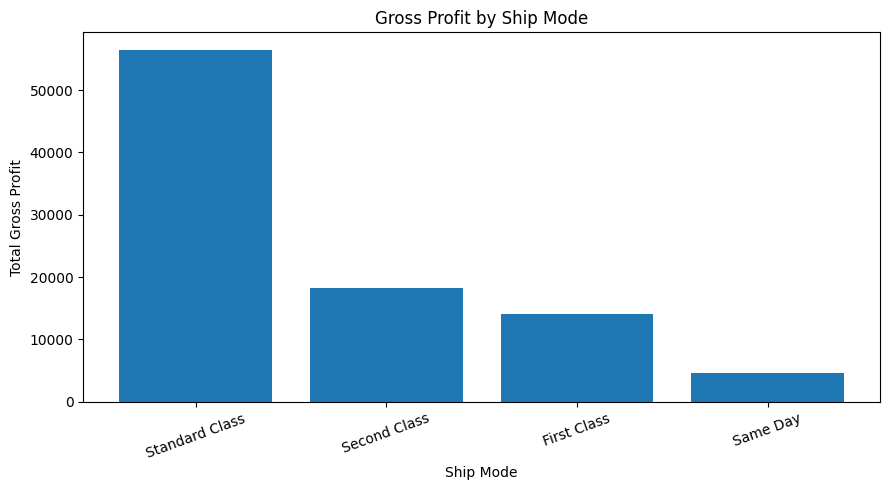

In [49]:
# Ship Mode — Gross Profit Chart

plt.figure(figsize=(9, 5))

plt.bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Total_Gross_Profit']
)

plt.title('Gross Profit by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Gross Profit')
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

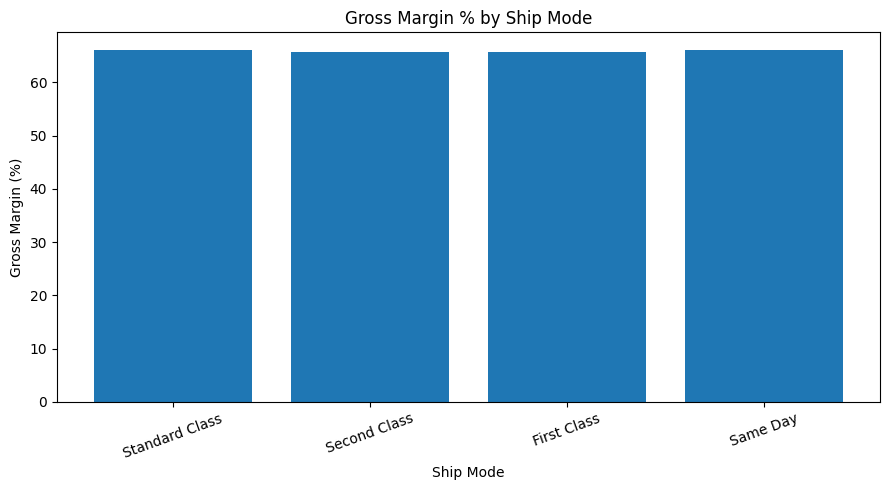

In [50]:
# Ship Mode — Gross Margin Chart

plt.figure(figsize=(9, 5))

plt.bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Gross Margin %']
)

plt.title('Gross Margin % by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Gross Margin (%)')
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [51]:
product_analysis[['Product Name', 'Total_Gross_Profit']].head(10)

,Product Name,Total_Gross_Profit
0,Wonka Bar - Fudge Mallows,16593.60
1,Wonka Bar - Milk Chocolate,17443.37
2,Wonka Bar - Nutty Crunch Surprise,16819.95
3,Wonka Bar -Scrumdiddlyumptious,19357.50
4,Wonka Bar - Triple Dazzle Caramel,18610.20
5,Fizzy Lifting Drinks,47.25
6,Wonka Gum,310.70
7,Kazookles,92.75
8,Lickable Wallpaper,3930.00
9,Everlasting Gobstopper,104.00


- Standard Class has the highest Sales and Gross Profit because of its much larger transaction volume.
- Same Day has the highest Gross Margin: 66.08%.
- First Class has the highest Profit per Unit: 2.45.
- Gross margins across all shipping modes are very close, roughly 65.7%–66.1%.
- Therefore, shipping mode shows much larger differences in sales/profit volume than in overall margin.



**Standard Class generated the highest sales and gross profit, while Same Day achieved the highest gross margin. First Class recorded the highest profit per unit. However, gross margins were relatively consistent across all shipping modes, indicating that shipping mode had a limited impact on overall margin percentage in this dataset.**

# 10. Customer Profitability **Analysis**

In [52]:
# Customer Analysis

customer_analysis = df.groupby('Customer ID').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

customer_analysis['Gross Margin %'] = (
    customer_analysis['Total_Gross_Profit'] /
    customer_analysis['Total_Sales']
) * 100

customer_analysis['Profit per Unit'] = (
    customer_analysis['Total_Gross_Profit'] /
    customer_analysis['Total_Units']
)

customer_analysis = customer_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

customer_analysis.head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
2326,131807,454.40,63,256.60,197.80,56.470070,4.073016
1124,115238,380.50,110,249.30,131.20,65.519054,2.266364
1637,122336,352.20,39,193.44,158.76,54.923339,4.960000
4690,164756,304.14,35,166.42,137.72,54.718222,4.754857
2887,139675,202.00,60,134.40,67.60,66.534653,2.240000
3748,151799,197.60,58,132.52,65.08,67.064777,2.284828
1770,124163,247.35,19,127.95,119.40,51.728320,6.734211
9,100111,182.41,52,125.93,56.48,69.036785,2.421731
4692,164770,232.40,19,122.50,109.90,52.710843,6.447368
1429,119508,177.14,50,122.34,54.80,69.064017,2.446800


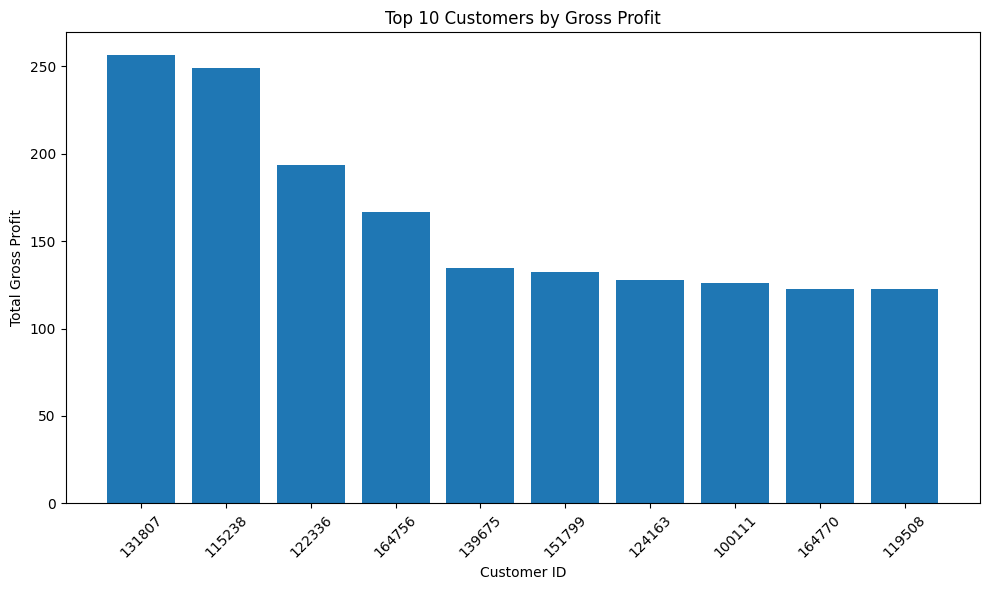

In [53]:
# Top 10 Customers — Gross Profit Chart

top10_customers = customer_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10_customers['Customer ID'].astype(str),
    top10_customers['Total_Gross_Profit']
)

plt.title('Top 10 Customers by Gross Profit')
plt.xlabel('Customer ID')
plt.ylabel('Total Gross Profit')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [54]:
# High & Low Margin Customers

# Top 10 customers by Gross Margin %

top_margin_customers = customer_analysis.sort_values(
    by='Gross Margin %',
    ascending=False
).head(10)

top_margin_customers[
    ['Customer ID', 'Total_Sales', 'Total_Gross_Profit',
     'Gross Margin %', 'Profit per Unit']
]

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin %,Profit per Unit
435,105662,50.47,39.47,78.204874,5.638571
3573,149146,9.00,7.00,77.777778,3.500000
4270,158834,29.70,22.50,75.757576,3.214286
4165,157490,104.96,78.90,75.171494,4.152632
4727,165323,33.30,25.00,75.075075,3.125000
25,100314,50.50,37.34,73.940594,4.148889
2537,134516,10.47,7.47,71.346705,2.490000
3171,143532,10.47,7.47,71.346705,2.490000
134,101623,20.94,14.94,71.346705,2.490000
3374,146360,20.94,14.94,71.346705,2.490000


In [55]:
# low-margin customers

# Bottom 10 customers by Gross Margin %

low_margin_customers = customer_analysis.sort_values(
    by='Gross Margin %',
    ascending=True
).head(10)

low_margin_customers[
    ['Customer ID', 'Total_Sales', 'Total_Gross_Profit',
     'Gross Margin %', 'Profit per Unit']
]

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin %,Profit per Unit
1319,117926,3.25,0.25,7.692308,0.25
685,109211,3.25,0.25,7.692308,0.25
1758,123981,3.25,0.25,7.692308,0.25
881,111864,6.50,0.50,7.692308,0.25
2042,127803,13.00,1.00,7.692308,0.25
362,104794,6.50,0.50,7.692308,0.25
2857,139290,6.50,0.50,7.692308,0.25
551,107314,9.75,0.75,7.692308,0.25
3755,151911,13.00,1.00,7.692308,0.25
4626,163923,13.00,1.00,7.692308,0.25


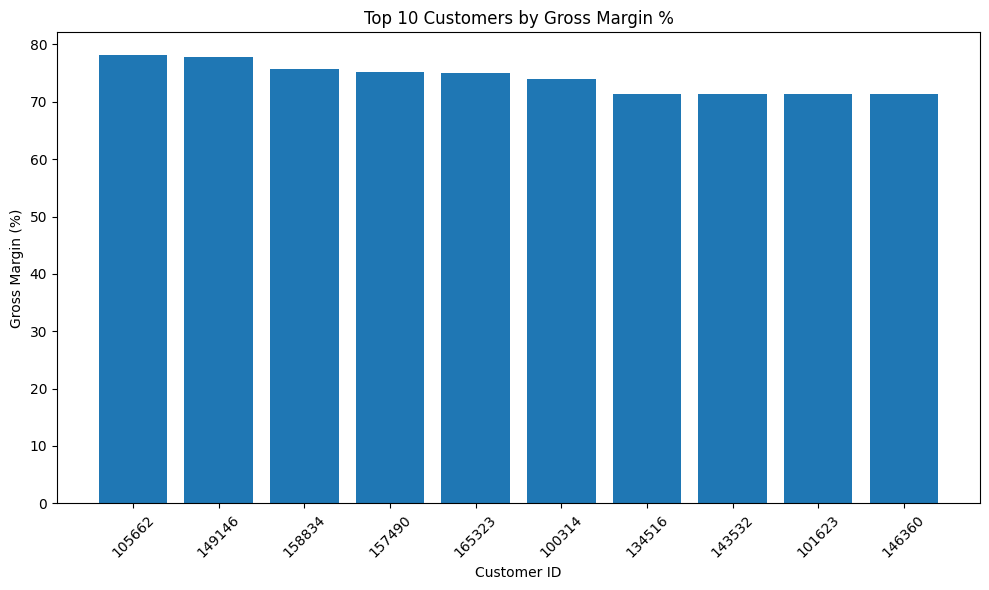

In [56]:
# High-Margin Customers Chart

plt.figure(figsize=(10, 6))

plt.bar(
    top_margin_customers['Customer ID'].astype(str),
    top_margin_customers['Gross Margin %']
)

plt.title('Top 10 Customers by Gross Margin %')
plt.xlabel('Customer ID')
plt.ylabel('Gross Margin (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

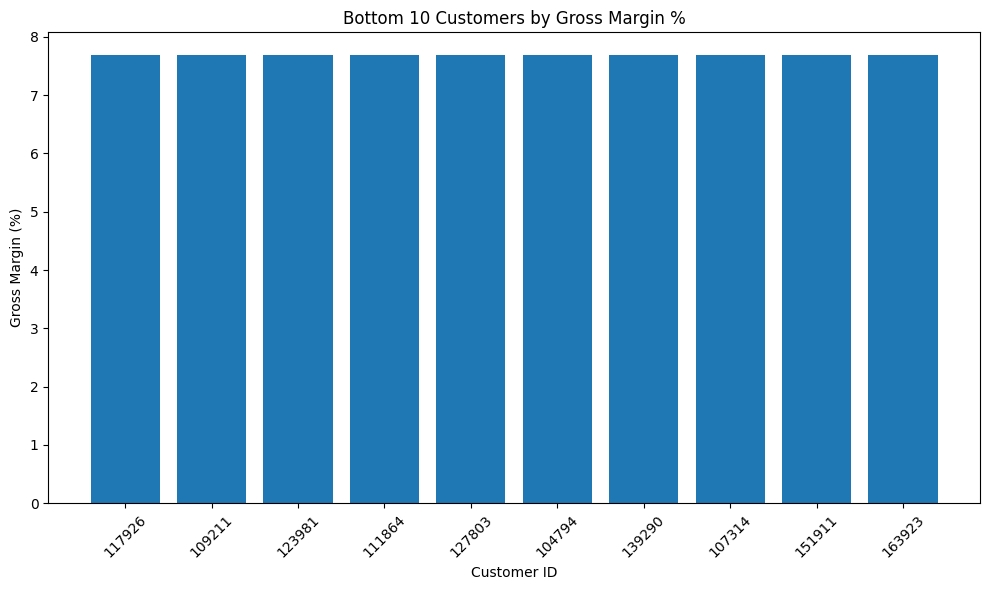

In [57]:
# Low-Margin Customers Chart

plt.figure(figsize=(10, 6))

plt.bar(
    low_margin_customers['Customer ID'].astype(str),
    low_margin_customers['Gross Margin %']
)

plt.title('Bottom 10 Customers by Gross Margin %')
plt.xlabel('Customer ID')
plt.ylabel('Gross Margin (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Customer-level profitability analysis revealed significant variation in gross margins. The highest customer margin was 78.20%, while the lowest margin was 7.69%. High-margin customers generated strong profitability percentages, although their overall contribution to gross profit depended on sales volume. This indicates that both margin percentage and customer sales volume should be considered when evaluating customer profitability.

# 11. **Division × Region Profitability Analysis**

In [58]:
# Division × Region Analysis

division_region_analysis = df.groupby(
    ['Division', 'Region']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Cost=('Cost', 'sum')
).reset_index()

division_region_analysis['Gross Margin %'] = (
    division_region_analysis['Total_Gross_Profit'] /
    division_region_analysis['Total_Sales']
) * 100

division_region_analysis['Profit per Unit'] = (
    division_region_analysis['Total_Gross_Profit'] /
    division_region_analysis['Total_Units']
)

division_region_analysis

,Division,Region,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
0,Chocolate,Atlantic,37580.63,10636,25355.29,12225.34,67.469039,2.383912
1,Chocolate,Gulf,21016.37,5952,14170.93,6845.44,67.428057,2.380869
2,Chocolate,Interior,30276.11,8573,20442.55,9833.56,67.520398,2.384527
3,Chocolate,Pacific,42819.79,12114,28855.85,13963.94,67.389051,2.382025
4,Other,Atlantic,3475.50,457,1537.10,1938.40,44.226730,3.363457
5,Other,Gulf,1143.50,235,467.50,676.00,40.883253,1.989362
6,Other,Interior,1686.75,222,792.55,894.20,46.986809,3.570045
7,Other,Pacific,3357.50,328,1536.30,1821.20,45.757260,4.683841
8,Sugar,Atlantic,141.11,66,81.31,59.80,57.621714,1.231970
9,Sugar,Gulf,87.39,22,62.24,25.15,71.220963,2.829091


In [59]:
# Sort according to Gross Profit

division_region_analysis.sort_values(
    by='Total_Gross_Profit',
    ascending=False
)

,Division,Region,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin %,Profit per Unit
3,Chocolate,Pacific,42819.79,12114,28855.85,13963.94,67.389051,2.382025
0,Chocolate,Atlantic,37580.63,10636,25355.29,12225.34,67.469039,2.383912
2,Chocolate,Interior,30276.11,8573,20442.55,9833.56,67.520398,2.384527
1,Chocolate,Gulf,21016.37,5952,14170.93,6845.44,67.428057,2.380869
4,Other,Atlantic,3475.50,457,1537.10,1938.40,44.226730,3.363457
7,Other,Pacific,3357.50,328,1536.30,1821.20,45.757260,4.683841
6,Other,Interior,1686.75,222,792.55,894.20,46.986809,3.570045
5,Other,Gulf,1143.50,235,467.50,676.00,40.883253,1.989362
11,Sugar,Pacific,124.24,24,93.79,30.45,75.490985,3.907917
8,Sugar,Atlantic,141.11,66,81.31,59.80,57.621714,1.231970


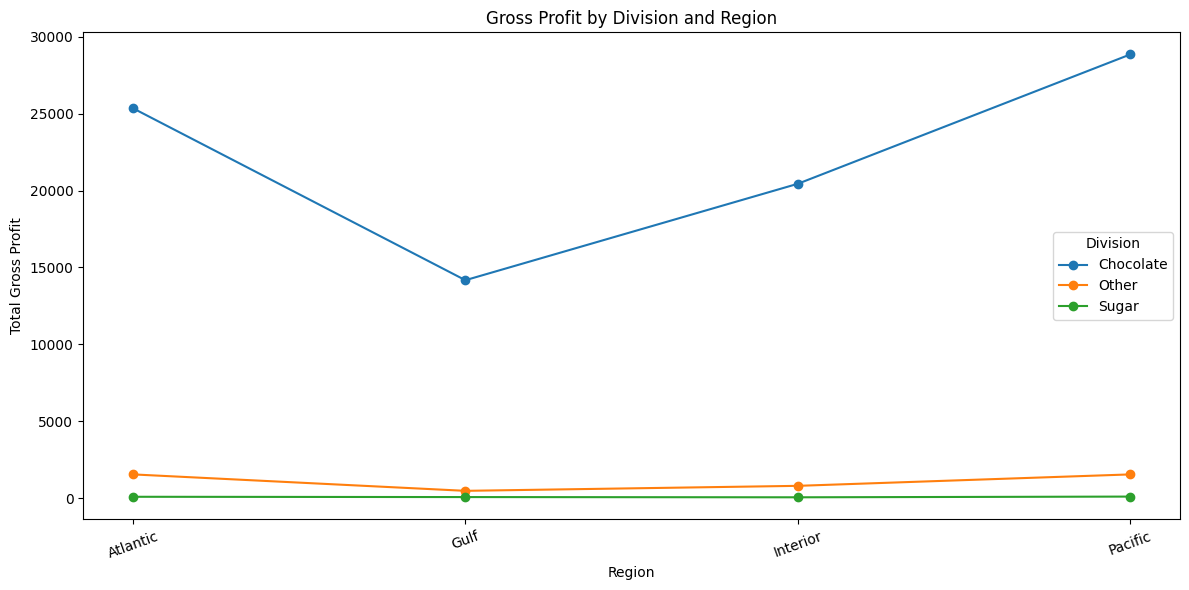

In [60]:
# Division × Region Gross Profit Chart

plt.figure(figsize=(12, 6))

for division in division_region_analysis['Division'].unique():
    data = division_region_analysis[
        division_region_analysis['Division'] == division
    ]

    plt.plot(
        data['Region'],
        data['Total_Gross_Profit'],
        marker='o',
        label=division
    )

plt.title('Gross Profit by Division and Region')
plt.xlabel('Region')
plt.ylabel('Total Gross Profit')
plt.legend(title='Division')
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

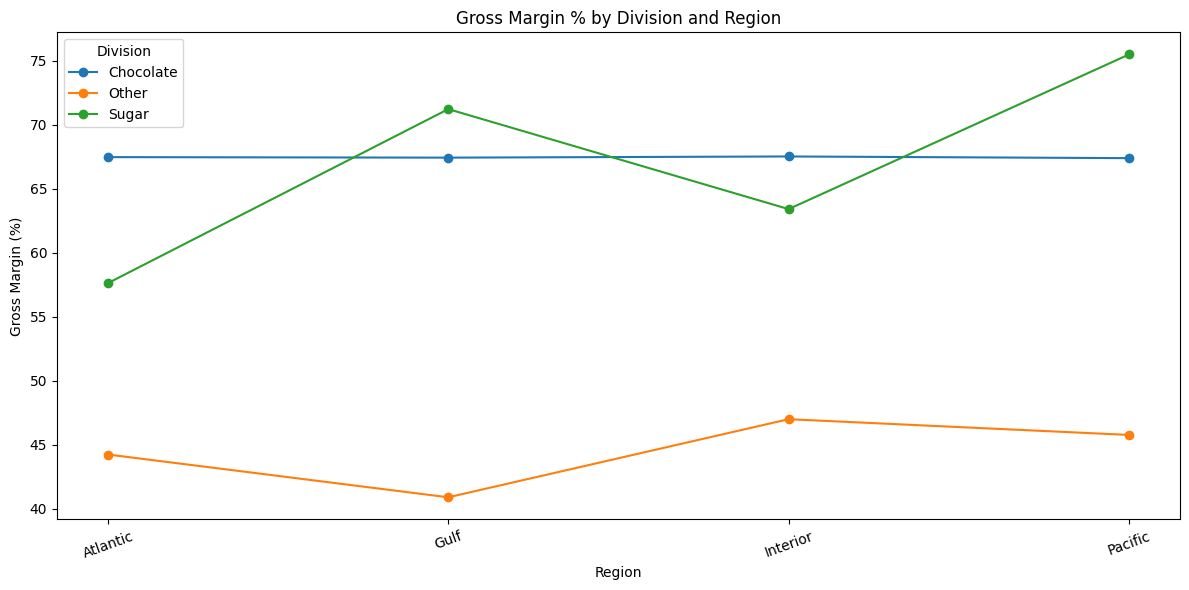

In [61]:
# Gross Margin % Chart

plt.figure(figsize=(12, 6))

for division in division_region_analysis['Division'].unique():
    data = division_region_analysis[
        division_region_analysis['Division'] == division
    ]

    plt.plot(
        data['Region'],
        data['Gross Margin %'],
        marker='o',
        label=division
    )

plt.title('Gross Margin % by Division and Region')
plt.xlabel('Region')
plt.ylabel('Gross Margin (%)')
plt.legend(title='Division')
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

Division-region analysis shows that Chocolate is the major contributor to sales and gross profit, with the Pacific region generating the highest sales and gross profit. Sugar has relatively high gross margins, particularly in the Pacific region, but its overall sales volume remains low. The Other division shows significant variation in profitability across regions, with the Pacific region achieving the highest profit per unit

# 12. **Cost & Profitability Efficiency Analysis**

In [62]:
# Overall Cost & Profitability Summary

 # Overall Cost & Profitability Efficiency Analysis

cost_profitability = pd.DataFrame({
    'Total Sales': [df['Sales'].sum()],
    'Total Cost': [df['Cost'].sum()],
    'Total Gross Profit': [df['Gross Profit'].sum()],
    'Overall Gross Margin %': [
        (df['Gross Profit'].sum() / df['Sales'].sum()) * 100
    ],
    'Profit per Unit': [
        df['Gross Profit'].sum() / df['Units'].sum()
    ],
    'Cost per Unit': [
        df['Cost'].sum() / df['Units'].sum()
    ]
})

cost_profitability

,Total Sales,Total Cost,Total Gross Profit,Overall Gross Margin %,Profit per Unit,Cost per Unit
0,141783.63,48340.83,93442.8,65.905211,2.417416,1.250604


Overall, the business generates a 65.91% gross margin, meaning approximately $65.91 of gross profit is generated for every $100 of sales. The average cost per unit is $1.25, while the average gross profit per unit is $2.42, indicating that the products generate substantially more profit than their average cost.

In [63]:
# Division-wise Cost Efficiency Analysis

# Division-wise Cost Efficiency Analysis

division_cost_efficiency = df.groupby('Division').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Units=('Units', 'sum')
).reset_index()

division_cost_efficiency['Gross Margin %'] = (
    division_cost_efficiency['Total_Gross_Profit'] /
    division_cost_efficiency['Total_Sales']
) * 100

division_cost_efficiency['Cost per Unit'] = (
    division_cost_efficiency['Total_Cost'] /
    division_cost_efficiency['Total_Units']
)

division_cost_efficiency['Profit per Unit'] = (
    division_cost_efficiency['Total_Gross_Profit'] /
    division_cost_efficiency['Total_Units']
)

division_cost_efficiency = division_cost_efficiency.round(2)

division_cost_efficiency

,Division,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Gross Margin %,Cost per Unit,Profit per Unit
0,Chocolate,131692.90,42868.28,88824.62,37275,67.45,1.15,2.38
1,Other,9663.25,5329.80,4333.45,1242,44.84,4.29,3.49
2,Sugar,427.48,142.75,284.73,137,66.61,1.04,2.08


In [64]:
# Region-wise Cost Efficiency Analysis

# Region-wise Cost Efficiency Analysis

region_cost_efficiency = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Units=('Units', 'sum')
).reset_index()

region_cost_efficiency['Gross Margin %'] = (
    region_cost_efficiency['Total_Gross_Profit'] /
    region_cost_efficiency['Total_Sales']
) * 100

region_cost_efficiency['Cost per Unit'] = (
    region_cost_efficiency['Total_Cost'] /
    region_cost_efficiency['Total_Units']
)

region_cost_efficiency['Profit per Unit'] = (
    region_cost_efficiency['Total_Gross_Profit'] /
    region_cost_efficiency['Total_Units']
)

region_cost_efficiency = region_cost_efficiency.round(2)

region_cost_efficiency

,Region,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Gross Margin %,Cost per Unit,Profit per Unit
0,Atlantic,41197.24,14223.54,26973.70,11159,65.47,1.27,2.42
1,Gulf,22247.26,7546.59,14700.67,6209,66.08,1.22,2.37
2,Interior,32037.60,10755.11,21282.49,8820,66.43,1.22,2.41
3,Pacific,46301.53,15815.59,30485.94,12466,65.84,1.27,2.45


Regional cost and profitability analysis indicates that the Pacific region generates the highest sales and gross profit, along with the highest profit per unit. The Interior region records the highest gross margin, while the Gulf and Interior regions maintain relatively lower cost per unit. Overall, profitability remains relatively consistent across regions, with gross margins ranging from approximately 65.5% to 66.4%.

In [65]:
# Cost vs Profitability Analysis

# Cost vs Profitability Analysis

cost_profit_analysis = df.groupby('Division').agg(
    Cost_per_Unit=('Cost', lambda x: x.sum() / df.loc[x.index, 'Units'].sum()),
    Profit_per_Unit=('Gross Profit', lambda x: x.sum() / df.loc[x.index, 'Units'].sum())
).reset_index()

cost_profit_analysis = cost_profit_analysis.round(2)

cost_profit_analysis

,Division,Cost_per_Unit,Profit_per_Unit
0,Chocolate,1.15,2.38
1,Other,4.29,3.49
2,Sugar,1.04,2.08


The cost versus profitability analysis shows considerable differences among divisions. The Other division has the highest cost per unit as well as the highest profit per unit, while Sugar has the lowest cost per unit and a comparatively lower profit per unit. Chocolate maintains a moderate cost per unit with a strong profit per unit and remains the largest contributor to overall business performance.

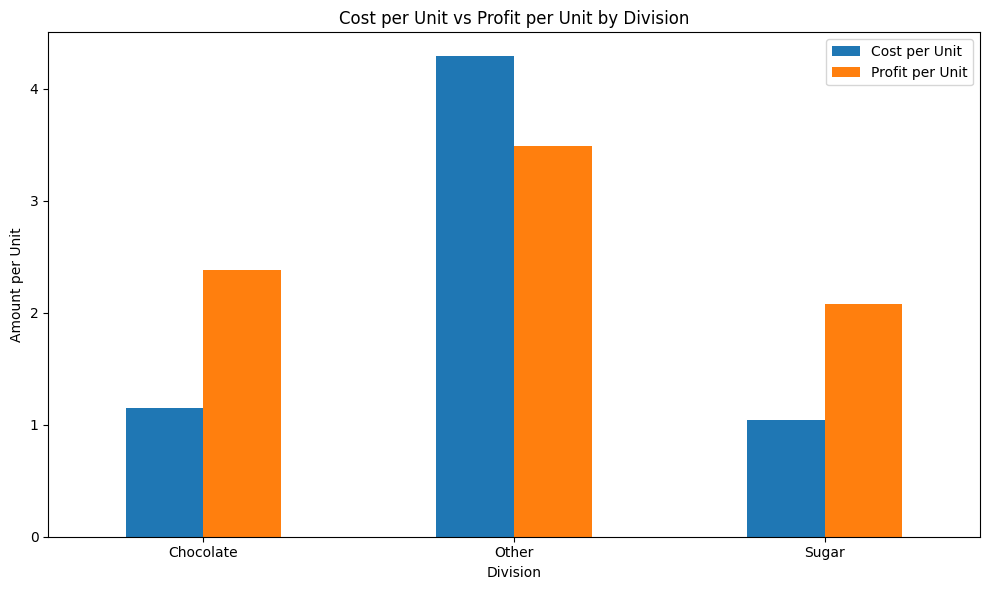

In [66]:
# Cost vs Profitability Visualization start

# Cost vs Profitability Visualization

import matplotlib.pyplot as plt

cost_profit_analysis.plot(
    x='Division',
    y=['Cost_per_Unit', 'Profit_per_Unit'],
    kind='bar',
    figsize=(10, 6)
)

plt.title('Cost per Unit vs Profit per Unit by Division')
plt.xlabel('Division')
plt.ylabel('Amount per Unit')
plt.xticks(rotation=0)
plt.legend(['Cost per Unit', 'Profit per Unit'])
plt.tight_layout()
plt.show()

In [67]:
# Division & Region Efficiency Summary

# Step 12.6 — Division & Region Efficiency Summary

efficiency_summary = df.groupby(['Division', 'Region']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Units=('Units', 'sum')
).reset_index()

efficiency_summary['Gross Margin %'] = (
    efficiency_summary['Total_Gross_Profit'] /
    efficiency_summary['Total_Sales']
) * 100

efficiency_summary['Cost per Unit'] = (
    efficiency_summary['Total_Cost'] /
    efficiency_summary['Total_Units']
)

efficiency_summary['Profit per Unit'] = (
    efficiency_summary['Total_Gross_Profit'] /
    efficiency_summary['Total_Units']
)

efficiency_summary = efficiency_summary.round(2)

efficiency_summary

,Division,Region,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Gross Margin %,Cost per Unit,Profit per Unit
0,Chocolate,Atlantic,37580.63,12225.34,25355.29,10636,67.47,1.15,2.38
1,Chocolate,Gulf,21016.37,6845.44,14170.93,5952,67.43,1.15,2.38
2,Chocolate,Interior,30276.11,9833.56,20442.55,8573,67.52,1.15,2.38
3,Chocolate,Pacific,42819.79,13963.94,28855.85,12114,67.39,1.15,2.38
4,Other,Atlantic,3475.50,1938.40,1537.10,457,44.23,4.24,3.36
5,Other,Gulf,1143.50,676.00,467.50,235,40.88,2.88,1.99
6,Other,Interior,1686.75,894.20,792.55,222,46.99,4.03,3.57
7,Other,Pacific,3357.50,1821.20,1536.30,328,45.76,5.55,4.68
8,Sugar,Atlantic,141.11,59.80,81.31,66,57.62,0.91,1.23
9,Sugar,Gulf,87.39,25.15,62.24,22,71.22,1.14,2.83


The cost and profitability efficiency analysis shows that Chocolate remains the primary contributor to overall sales and gross profit, particularly in the Pacific region. The Other division has higher unit costs but also generates higher profit per unit in the Pacific region. Sugar records very high gross margins in some regions, especially Pacific, but its overall sales contribution is limited. The analysis highlights the importance of evaluating both cost efficiency and profitability rather than relying on a single metric.

# Key Findings

- The business generated total sales of approximately $141,783.63 and total gross profit of $93,442.80.
- Overall gross margin was approximately 65.91%.
- Chocolate was the major contributor to total sales and gross profit.
- The Pacific region generated the highest total sales and gross profit among the four regions.
- Product-level analysis identified significant differences in gross margin and profit per unit.
- Pareto analysis showed that a relatively small number of products contribute a large share of total gross profit.
- Sugar products recorded high gross margins in some regions, particularly Pacific, but their overall sales contribution was relatively small.
- Cost efficiency analysis showed differences in cost per unit and profit per unit across divisions and regions.

# Business Recommendations

1. Focus on high-performing Chocolate products and regions to sustain revenue and gross profit.

2. Monitor high-margin products and consider strategies to increase their sales volume.

3. Review low-margin products and evaluate pricing, sourcing, and cost structures.

4. Investigate the Other division because it has relatively high cost per unit but also generates high profit per unit in some regions.

5. Use region-level profitability analysis to identify opportunities for improving sales and margins.

6. Monitor product-level profitability regularly to identify products that contribute significantly to total gross profit.

7. Balance sales volume and margin when making product and regional business decisions rather than relying on a single profitability metric.

# Conclusion

The Product Line Profitability & Margin Performance Analysis provided a detailed view of sales, costs, gross profit, gross margins, and profitability across products, divisions, regions, states, customers, and shipping modes.

The analysis shows that Chocolate is the primary contributor to overall business performance, while profitability varies across products and regions. The Pacific region records strong sales and gross profit, while some Sugar products achieve high gross margins despite their relatively low sales contribution.

The cost and profitability analysis further demonstrates that evaluating both cost per unit and profit per unit is important for understanding business efficiency.

Overall, the analysis provides useful data-driven insights that can support product, regional, pricing, and profitability-related business decisions.